# 차원축소
- 목적
    - 여러 특성을 2차원 또는 3차원으로 줄여 시각화
    - 서로 강하게 관련된 특성 압축
    - 모델 학습에 필요한 특성 수 축소 (계산량 목적)

      

- PCA : 비지도 차원축소 (데이터의 분산이 큰 방향을 찾는 축 설계)
- LDA : 지도 차원축소 (클래스가 잘 구분되는 방향을 찾는 축 설계)

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris


plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [31]:
iris_data = load_iris()
iris_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [32]:
iris_df = pd.DataFrame(
    iris_data.data,
    columns= iris_data.feature_names
)

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [33]:
iris_df['target'] = iris_data.target
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [34]:
iris_data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [35]:
iris_df['target_name'] = iris_df['target'].map(
    lambda x: iris_data.target_names[x]
)

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


- # PCA 적용하기
    - 거리와 분산을 기준으로 계산하기 때문에 PCA 적용전 스케일링 수행해야 한다.

In [36]:
from sklearn.preprocessing import StandardScaler

X_iris = iris_df.drop(['target', 'target_name'], axis =1)
y_iris = iris_df['target']

scaler = StandardScaler()   # 학습데이터는 학습/변환 -> 테스트 데이터 학습된 기준으로 변환만 진행
iris_scaled = scaler.fit_transform(X_iris)  # 평균 0, 표준편차 1 기준으로 변환  

iris_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
iris_pca = pca.fit_transform(iris_scaled)

irispca_df = pd.DataFrame(
    iris_pca,
    columns= ['pca_component_1','pca_component_2']
)

irispca_df['target'] = y_iris
irispca_df['target_name'] = iris_df['target_name']

irispca_df

,pca_component_1,pca_component_2,target,target_name
0,-2.264703,0.480027,0,setosa
1,-2.080961,-0.674134,0,setosa
2,-2.364229,-0.341908,0,setosa
3,-2.299384,-0.597395,0,setosa
4,-2.389842,0.646835,0,setosa
...,...,...,...,...
145,1.870503,0.386966,2,virginica
146,1.564580,-0.896687,2,virginica
147,1.521170,0.269069,2,virginica
148,1.372788,1.011254,2,virginica


- PCA 설명 분산 비율 확인 (보존율)

In [38]:
pca.explained_variance_ratio_  # 각 주성분이 설명하는 분산 비율

array([0.72962445, 0.22850762])

In [39]:
pca.explained_variance_ratio_.sum() # 각 주성분이 설명하는 전체 비율

np.float64(0.9581320720000165)

96%정도 보존되어 손실이 4%정도 발생한 걸로 보여 꽤 잘 압축된 것으로 보입니다.  
PCA는 정답을 잘 맞추는 방향이 아니라 데이터의 분산을 얼머나 많이 보존했는가를 볼  수있습니다.

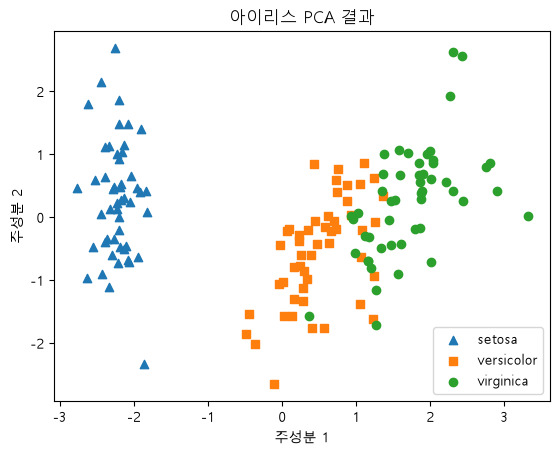

In [40]:
markers = ['^','s','o']

for i, marker in enumerate(markers):
    x_data = irispca_df[irispca_df['target']==i]['pca_component_1']
    y_data = irispca_df[irispca_df['target']==i]['pca_component_2']

    plt.scatter(
        x_data,
        y_data,
        marker= marker,
        label = iris_data.target_names[i]
    )

plt.legend()
plt.xlabel('주성분 1')
plt.ylabel('주성분 2')
plt.title('아이리스 PCA 결과')
plt.show()

2차원 데이터로 축소를 해서 본다는 것은 모델 성능을 끌어올린다거나, 모델 성능을 평가한다기 보다는 고차원 데이터를 사람이 볼 수 있는 형태로 줄여 구조를 확인하는 시각화 목적

- LDA
    - 클래스가 잘 나뉘는 방향을 찾는 목적
    - LDA의 최대 차원수는 target 클래스 -1개 (iris 데이터셋의 경우 꽃 종류 3종 -> 최대 차원수 2개)


In [41]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components= 2)   # 클래스 3개 -> 최대 2차원
iris_lda = lda.fit_transform(iris_scaled, y_iris)   # 정답 라벨도 합께 사용

irislda_df = pd.DataFrame(
    iris_lda,
    columns=['lda_component_1','lda_component_2']
    )

irislda_df['target'] = y_iris
irislda_df['target_name'] = iris_df['target_name']

irislda_df

,lda_component_1,lda_component_2,target,target_name
0,8.061800,-0.300421,0,setosa
1,7.128688,0.786660,0,setosa
2,7.489828,0.265384,0,setosa
3,6.813201,0.670631,0,setosa
4,8.132309,-0.514463,0,setosa
...,...,...,...,...
145,-5.645003,-1.677717,2,virginica
146,-5.179565,0.363475,2,virginica
147,-4.967741,-0.821141,2,virginica
148,-5.886145,-2.345091,2,virginica


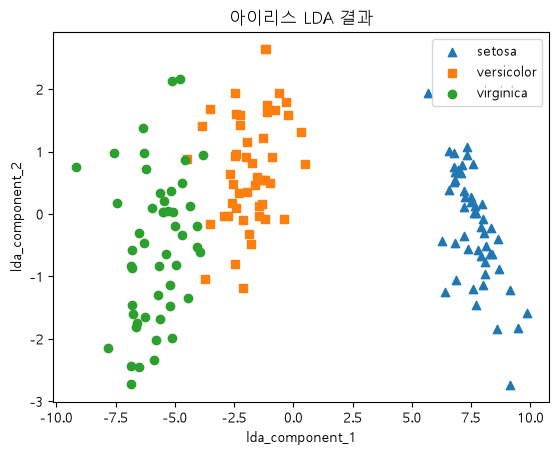

In [42]:
markers = ['^','s','o']

for i, marker in enumerate(markers):
    x_data = irislda_df[irislda_df['target']==i]['lda_component_1']
    y_data = irislda_df[irislda_df['target']==i]['lda_component_2']

    plt.scatter(
        x_data,
        y_data,
        marker= marker,
        label = iris_data.target_names[i]
    )

plt.legend()
plt.xlabel('lda_component_1')
plt.ylabel('lda_component_2')
plt.title('아이리스 LDA 결과')
plt.show()

지도학습 분류 문제에서 PCA보다 LDA 클래스 구분이 더 명확하게 차원축소된다.

|구분|PCA|LDA|
|---|---|---|
|학습방법|비지도 학습|지도 학습|
|정답 라벨 사용|사용 안함|사용함|
|목적|데이터 분산을 최대한 보존|클래스가 잘 나뉘는 방향 탐색|
|주요 사용|시각화, 압축, 노이즈 감소|분류 전처러, 클래스 분리 시각화|

- 신용카드 데이터에서 상곽관계 높은 변수 줄인다

In [43]:
df = pd.read_excel(
    'data/pca_credit_card.xls',
    header=1,  # header=0부터 엑셀의 첫번째 행
    sheet_name= 'Data'
)

df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [ ]:
df = df.rename(
    columns={
        'PAY_0' : "PAY_1",
        'default payment next month': 'default'
    }
)

df = df.drop('ID',axis=1)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [48]:
X_data = df.drop('default',axis = 1)
y_data = df['default']

print(X_data.shape, y_data.shape)

(30000, 23) (30000,)


In [ ]:
target_summary = pd.DataFrame({ 
    'count' : y_data.value_counts(),                # 고유값별 갯수
    'ratio' : y_data.value_counts(normalize=True)   # 비율로 표시
})

target_summary

,count,ratio
default,,
0,23364,0.7788
1,6636,0.2212


상관관계 확인
- 상관관계가 높은 여러 변수를 확인하고, 차원 축소 진행

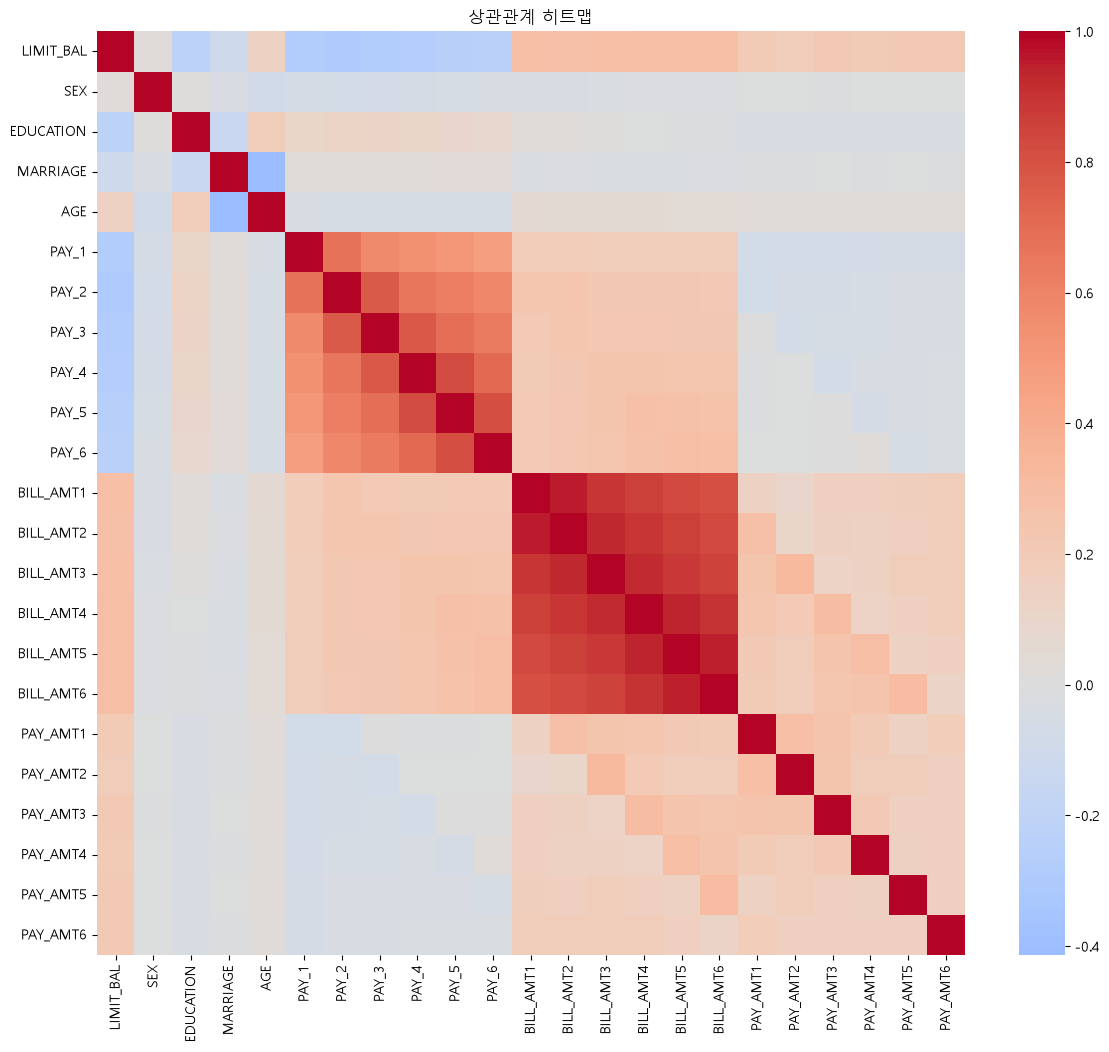

In [ ]:
corr = X_data.corr()  # 피어슨 상관계수 계산

plt.figure(figsize= (14,12))
sns.heatmap(corr, cmap = 'coolwarm', center = 0)
plt.title('상관관계 히트맵')
plt.show()

BILL_AMT1~BILL_AMT6 는 강한 양의 상관관계를 보이기 때문에 차원축소를 해도 결과에 큰 차이가 없을 것으로 보임

In [52]:
bill_features = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']

X_bill = X_data[bill_features]

X_bill

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
0,3913,3102,689,0,0,0
1,2682,1725,2682,3272,3455,3261
2,29239,14027,13559,14331,14948,15549
3,46990,48233,49291,28314,28959,29547
4,8617,5670,35835,20940,19146,19131
...,...,...,...,...,...,...
29995,188948,192815,208365,88004,31237,15980
29996,1683,1828,3502,8979,5190,0
29997,3565,3356,2758,20878,20582,19357
29998,-1645,78379,76304,52774,11855,48944


PCA적용전 스케일링

In [53]:
scaler = StandardScaler()
X_bill_scaled = scaler.fit_transform(X_bill)

X_bill_scaled

array([[-0.64250107, -0.64739923, -0.66799331, -0.67249727, -0.66305853,
        -0.65272422],
       [-0.65921875, -0.66674657, -0.63925429, -0.62163594, -0.60622927,
        -0.59796638],
       [-0.29855966, -0.49389911, -0.48240819, -0.44973025, -0.41718767,
        -0.39162956],
       ...,
       [-0.64722711, -0.64383044, -0.63815838, -0.34796096, -0.32451732,
        -0.32768664],
       [-0.71798186,  0.41026929,  0.42237335,  0.14784373, -0.46806261,
         0.16913036],
       [-0.04473888, -0.00385085,  0.03966713, -0.10458204, -0.12966943,
        -0.39559241]], shape=(30000, 6))

In [ ]:
pca_bill = PCA(n_components=2)  # 6개 금액 관련 컬럼을 2개 주성분으로 축소
X_bill_pca = pca_bill.fit_transform(X_bill_scaled)

X_bill_pca

array([[-1.61114812,  0.01247912],
       [-1.54759523, -0.06234401],
       [-1.03587378,  0.01125622],
       ...,
       [-1.19551872, -0.3595072 ],
       [-0.00829343, -0.04995798],
       [-0.25828552,  0.26525237]], shape=(30000, 2))

In [ ]:
# 주성분별 설명 분산 비율 확인
pca_result = pd.DataFrame({
    "component": ['PCA1','PCA2'],
    'explained_variance_ratio' : pca_bill.explained_variance_ratio_
})
pca_result

,component,explained_variance_ratio
0,PCA1,5.433496
1,PCA2,0.305930


In [59]:
# 총 설명 비율 확인
pca_bill.explained_variance_ratio_.sum()

np.float64(0.9565392265910996)

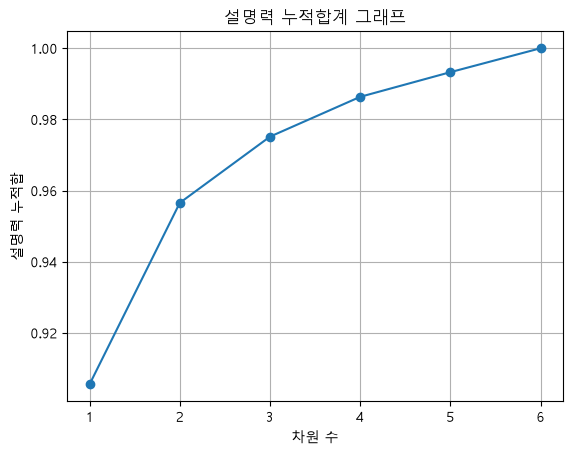

In [61]:
pca_full = PCA()
pca_full.fit(X_bill_scaled)


cum_ratio = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1,len(cum_ratio)+1), cum_ratio, marker = 'o')
plt.xticks(range(1,len(cum_ratio)+1))
plt.xlabel('차원 수')
plt.ylabel('설명력 누적합')
plt.title('설명력 누적합계 그래프')
plt.grid(True)
plt.show()

- 차원축소 전후 모델 성능 비교
    - 잘못된 방식 : Scaler와 PCA를 먼저 학습을 진행한 후, train_test_split을 진행한 경우  
        -> 테스트 데이터의 정보가 전처리 결과에 미리 반영된다.
    - 순서
        - train/test 분리
        - train 데이터로 Scaler, PCA 학습
        - test 데이터는 train데이터로 학습된 전처리 객체로 변환만 진행
        - 모델 학습 및 평가

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score,precision_score,f1_score
from xgboost import train


X_train, X_test, y_train, y_test = train_test_split(
    X_bill,
    y_data,
    test_size= 0.2,
    random_state= 42,
    stratify = y_data
)

print(f"X 학습 데이터 : {X_train.shape}")
print(f"X 테스트 데이터 : {X_test.shape}")

X 학습 데이터 : (24000, 6)
X 테스트 데이터 : (6000, 6)


In [ ]:
# baseline_model = Pipeline([
#     ('scaler', StandardScaler()),   # train데이터 기준으로 스케일링
#     ('model', LogisticRegression(max_iter = 1000))
# ])
lr_model = LogisticRegression(max_iter = 1000)
scaler = StandardScaler()

X_train_before = scaler.fit_transform(X_train)


lr_model.fit(X_train_before,y_train)
X_test_scaled = scaler.transform(X_test)
baseline_pred = lr_model.predict(X_test_scaled)

print(f"차원 축소 전 모델의 정확도 : {accuracy_score(y_test,baseline_pred)}")
print(f"차원 축소 전 모델의 f1스코어 : {f1_score(y_test,baseline_pred)}")


차원 축소 전 모델의 정확도 : 0.7788333333333334
차원 축소 전 모델의 f1스코어 : 0.0


In [ ]:
# pca_model = Pipeline([
#     ('scaler', StandardScaler()),
#     ("pca",PCA(n_components=2)),
#     ('model', LogisticRegression(max_iter = 1000))
# ])
lr_model = LogisticRegression(max_iter = 1000)
scaler = StandardScaler()

X_train_new = scaler.fit_transform(X_train)
pca = PCA(n_components=2)
new_pca = pca.fit_transform(X_train_new)


lr_model.fit(new_pca,y_train)

X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

pca_pred = lr_model.predict(X_test_pca)

print(f"차원 축소 전 모델의 정확도 : {accuracy_score(y_test,pca_pred)}")


차원 축소 전 모델의 정확도 : 0.7788333333333334


In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test,baseline_pred))
print(classification_report(y_test,pca_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4673
           1       0.00      0.00      0.00      1327

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.68      6000

              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4673
           1       0.00      0.00      0.00      1327

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.68      6000



c:\Users\UK\SKN\ML\ml_venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\UK\SKN\ML\ml_venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\UK\SKN\ML\ml_venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\UK\SKN\ML\ml_

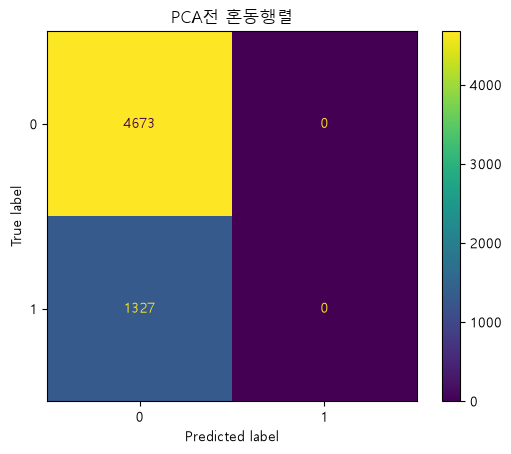

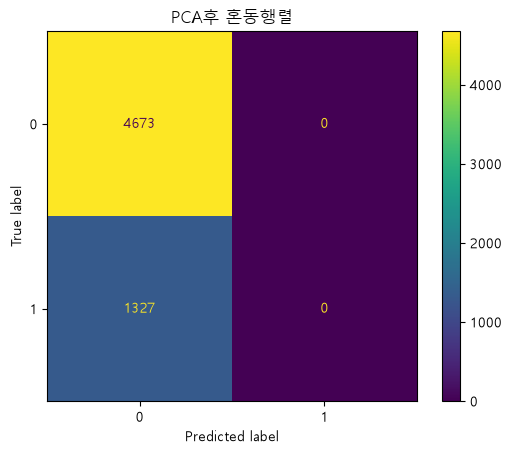

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred)
plt.title('PCA전 혼동행렬')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pca_pred)
plt.title('PCA후 혼동행렬')
plt.show()

- PCA는 라벨 없이 데이터의 분산이 큰 방향을 찾아 차원을 줄인다.
- LDA는 라벨을 사용해서 클래스가 잘 분리되는 방향으로 차원을 줄인다.
- PCA 전 스케일링 필수
- 상관관계가 높은 컬럼들은 PCA를 통해 압축한다.
- 성능 비교시 train/test 데이터를 먼저 나눈 후, trin 데이터로만 전처리 객체 학습
- 차원축소 자체는 성능향상 목적보다는 시각화 및 특성 압축을 통한 계산량 감소에 있다.

## 추가 실습
- LDA를 통해 차원 축소 진행
- PAY 1 ~ PAY 6 컬럼에도 차원축소 진행해보기
- LogisticRegeresion이 아닌 다른 모델 사용해보기